# 🛒 Walmart Weekly Sales — Predicting Weekly Store Sales

## Introduction

### Why this project?

This project is set in the context of **retail and large-scale distribution marketing**,
where the main goal is to **predict the weekly sales amount** of Walmart stores
based on economic and operational indicators.

Two key stakes motivate this analysis:

- **Understand the factors influencing sales** (unemployment rate, CPI, fuel price,
  holiday periods),
- **Plan marketing campaigns** by anticipating sales variations according to the
  economic context.

### Who is this for?

This project is designed for:

- **Walmart's marketing team**, looking to optimize the timing and targeting of
  their promotional campaigns,
- **Operational teams**, seeking to better allocate resources based on
  store-level sales forecasts.

### Main Steps

1. **Exploratory Data Analysis (EDA)**: statistical analysis, visualizations and
   understanding of weekly sales behavior.
2. **Preprocessing**: data cleaning, categorical variable encoding,
   normalization and outlier removal.
3. **Baseline Modeling**: linear regression to establish a performance reference.
4. **Regularization**: training Ridge and Lasso models to reduce overfitting
   and improve generalization.

The final deliverable is a **weekly sales prediction model**, accompanied by a
coefficient analysis identifying the most influential factors on Walmart
store revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## **1. EDA — Exploratory Data Analysis**

### Goal
The objective of this step is to better understand the structure and content of the dataset before any modeling. This helps identify relevant variables, detect potential anomalies or missing values, and guide preprocessing decisions.

### Actions
Here are the main actions performed during this phase:

1. **Loaded the dataset** `Walmart_Store_sales.csv` and displayed the first rows.
2. **Checked column types** and converted the `Date` column to datetime format.
3. **Analyzed missing values** across all columns.
4. **Checked for duplicates** — no strict or functional duplicates (`Store + Date`) detected.
5. **Explored the distribution of the target variable** `Weekly_Sales` :
   - Distribution and boxplot analysis
   - Skewness close to zero → near-symmetric distribution
6. **Analyzed the distribution of numerical features** :
   - `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`
   - Histograms and boxplots for each variable
7. **Detected outliers using the ±3σ rule** :
   - No outliers on `Temperature_C`, `Fuel_Price`, `CPI`
   - **Outliers detected on `Unemployment`** — all from the same store
8. **Deep analysis of the unemployment rate** :
   - Right-skewed distribution
   - Outlier threshold identified
9. **Analyzed sales by Store and Holiday_Flag** :
   - Strong sales disparity across stores
   - Holiday weeks show slightly higher sales than non-holiday weeks
10. **Temporal analysis** :
    - Sales evolution over the full period covered by the dataset
    - Notable sales peak in **December** — Christmas seasonal effect
11. **Correlation matrix** :
    - `CPI` is the most correlated feature with `Weekly_Sales`
    - Strong correlation between `Fuel_Price` and `Year` → **multicollinearity risk** to monitor during modeling
    - `Store` and `CPI` are strongly correlated

In [2]:
datas = pd.read_csv("datas/Walmart_Store_sales.csv")
datas.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [3]:
datas.shape

(150, 8)

In [4]:
datas.dtypes

Store           float64
Date             object
Weekly_Sales    float64
Holiday_Flag    float64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [5]:
datas["Date"] = pd.to_datetime(datas["Date"], errors="coerce", dayfirst=True)

print("Range date:", f"{datas["Date"].min()} - ", f"{datas["Date"].max()}")

Range date: 2010-02-05 00:00:00 -  2012-10-19 00:00:00


In [6]:
print(((datas.isnull().sum() / datas.shape[0]) * 100).round(2))

Store            0.00
Date            12.00
Weekly_Sales     9.33
Holiday_Flag     8.00
Temperature     12.00
Fuel_Price       9.33
CPI              8.00
Unemployment    10.00
dtype: float64


In [7]:
datas["Temperature_C"] = (datas["Temperature"] - 32) * 5 / 9
datas["Temperature_C"] = datas["Temperature_C"].round(2)

datas = datas.dropna(subset=["Date"])

datas["Year"] = datas["Date"].dt.year
datas["Month"] = datas["Date"].dt.month
datas["Day"] = datas["Date"].dt.day
datas["dayOfWeek"] = datas["Date"].dt.weekday

datas["Store"] = datas["Store"].astype(int)

print("Types of columns:")
display(datas.dtypes)

Types of columns:


Store                     int64
Date             datetime64[ns]
Weekly_Sales            float64
Holiday_Flag            float64
Temperature             float64
Fuel_Price              float64
CPI                     float64
Unemployment            float64
Temperature_C           float64
Year                      int32
Month                     int32
Day                       int32
dayOfWeek                 int32
dtype: object

In [8]:
datas.describe(include="all").round(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Temperature_C,Year,Month,Day,dayOfWeek
count,132.00,132,118.00,122.00,118.00,119.00,122.00,120.00,118.00,132.00,132.00,132.00,132.0
mean,9.79,2011-05-07 09:05:27.272727296,1257271.14,0.08,61.33,3.30,179.80,7.60,16.30,2010.86,6.39,16.52,4.0
min,1.00,2010-02-05 00:00:00,268929.03,0.00,18.79,2.51,126.11,5.14,-7.34,2010.00,1.00,1.00,4.0
25%,4.00,2010-08-16 12:00:00,577427.56,0.00,45.97,2.85,131.97,6.55,7.76,2010.00,4.00,10.00,4.0
50%,8.50,2011-05-09 12:00:00,1331000.66,0.00,62.31,3.31,197.66,7.48,16.84,2011.00,6.00,17.00,4.0
75%,15.00,2012-01-14 18:00:00,1810591.02,0.00,76.09,3.69,214.90,8.12,24.50,2012.00,9.00,24.00,4.0
max,20.00,2012-10-19 00:00:00,2771397.17,1.00,91.65,4.19,226.97,14.31,33.14,2012.00,12.00,31.00,4.0
std,6.19,NaN,662505.57,0.28,17.86,0.48,39.91,1.63,9.92,0.81,3.21,8.31,0.0


In [9]:
for col in datas.columns:
    print(f"{col} : {datas[col].nunique()} valeurs uniques")

Store : 20 valeurs uniques
Date : 85 valeurs uniques
Weekly_Sales : 118 valeurs uniques
Holiday_Flag : 2 valeurs uniques
Temperature : 118 valeurs uniques
Fuel_Price : 107 valeurs uniques
CPI : 120 valeurs uniques
Unemployment : 93 valeurs uniques
Temperature_C : 118 valeurs uniques
Year : 3 valeurs uniques
Month : 12 valeurs uniques
Day : 30 valeurs uniques
dayOfWeek : 1 valeurs uniques


Lignes 100% identiques : 0
Doublons Store + Date  : 0
Aucun doublon fonctionnel détecté sur Store + Date.


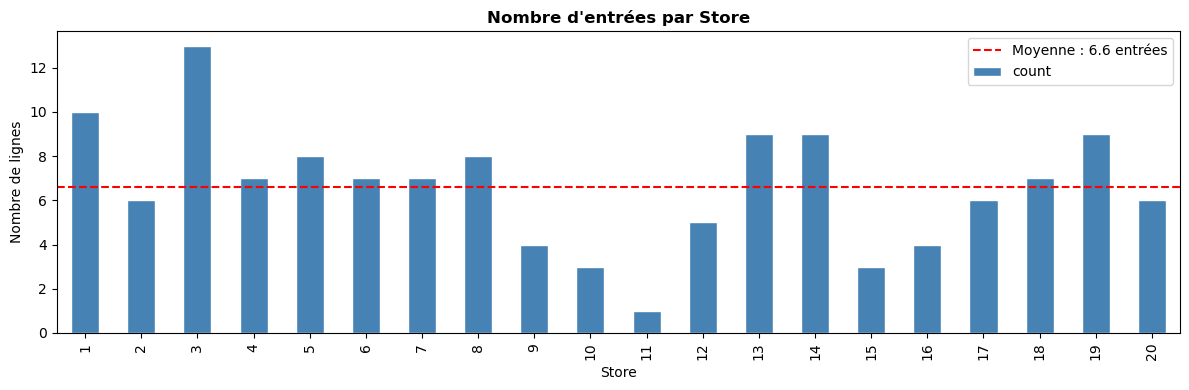


Entrées par store — Min : 1 | Max : 13 | Moy : 6.6


In [10]:
duplicates_full = datas.duplicated()
print(f"Lignes 100% identiques : {duplicates_full.sum()}")

duplicates_key = datas.duplicated(subset=["Store", "Date"], keep=False)
print(f"Doublons Store + Date  : {duplicates_key.sum()}")

if duplicates_key.sum() > 0:
    print("\nLignes concernées :")
    display(
        datas[duplicates_key]
        .sort_values(["Store", "Date"])
        .reset_index(drop=True)
    )
else:
    print("Aucun doublon fonctionnel détecté sur Store + Date.")

store_counts = datas["Store"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
store_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.axhline(store_counts.mean(), color="red", linestyle="--", label=f"Moyenne : {store_counts.mean():.1f} entrées")
plt.title("Nombre d'entrées par Store", fontweight="bold")
plt.xlabel("Store")
plt.ylabel("Nombre de lignes")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nEntrées par store — Min : {store_counts.min()} | Max : {store_counts.max()} | Moy : {store_counts.mean():.1f}")

               Valeurs manquantes  Pourcentage (%)
Weekly_Sales                   14            10.61
Temperature                    14            10.61
Temperature_C                  14            10.61
Fuel_Price                     13             9.85
Unemployment                   12             9.09
Holiday_Flag                   10             7.58
CPI                            10             7.58
Store                           0             0.00
Date                            0             0.00
Year                            0             0.00
Month                           0             0.00
Day                             0             0.00
dayOfWeek                       0             0.00


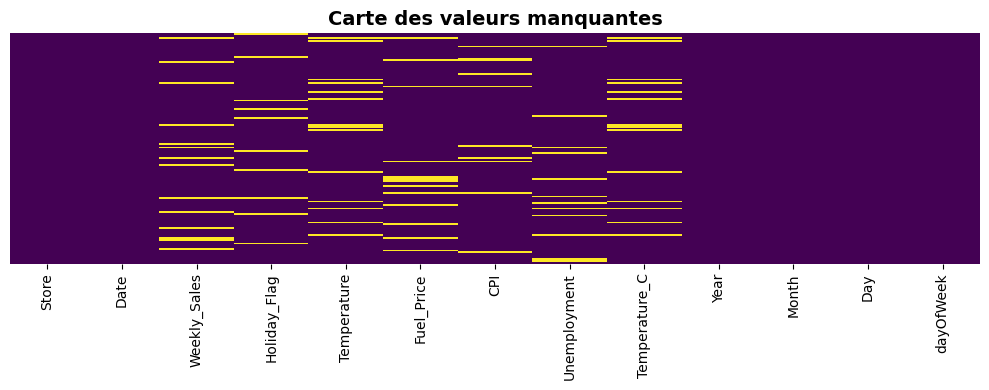

In [11]:
missing = datas.isnull().sum()
missing_pct = (missing / len(datas) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing,
    "Pourcentage (%)": missing_pct
}).sort_values("Valeurs manquantes", ascending=False)

print(missing_df)

plt.figure(figsize=(10, 4))
sns.heatmap(datas.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Carte des valeurs manquantes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

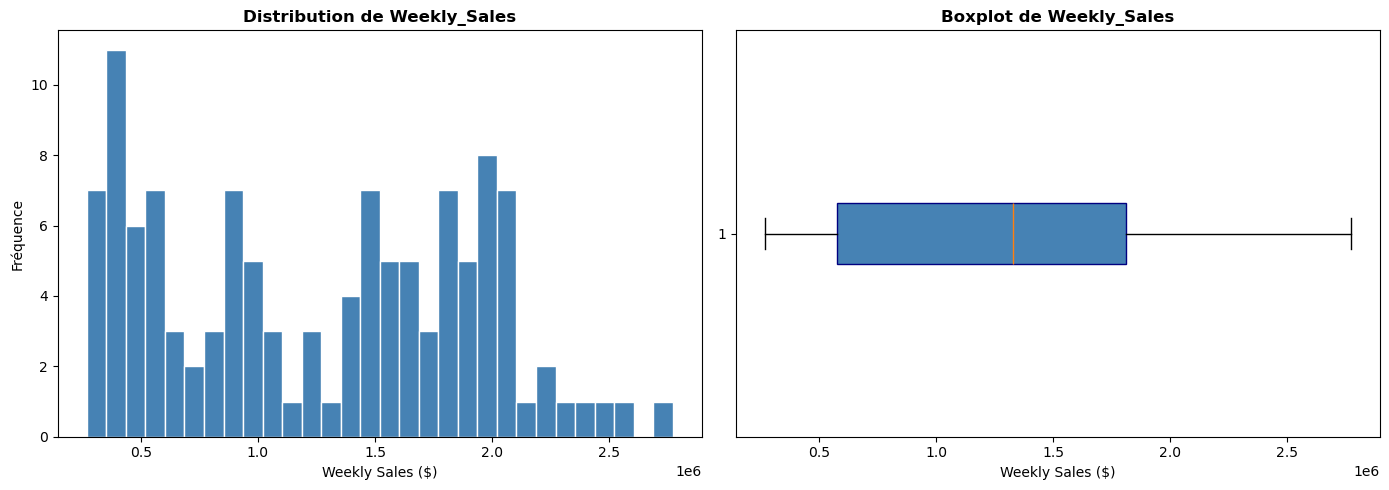

Moyenne   : 1,257,271 $
Médiane   : 1,331,001 $
Std       : 662,506 $
Skewness  : 0.085


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(datas["Weekly_Sales"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de Weekly_Sales", fontweight="bold")
axes[0].set_xlabel("Weekly Sales ($)")
axes[0].set_ylabel("Fréquence")

# Boxplot
axes[1].boxplot(datas["Weekly_Sales"].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"))
axes[1].set_title("Boxplot de Weekly_Sales", fontweight="bold")
axes[1].set_xlabel("Weekly Sales ($)")

plt.tight_layout()
plt.show()

print(f"Moyenne   : {datas['Weekly_Sales'].mean():,.0f} $")
print(f"Médiane   : {datas['Weekly_Sales'].median():,.0f} $")
print(f"Std       : {datas['Weekly_Sales'].std():,.0f} $")
print(f"Skewness  : {datas['Weekly_Sales'].skew():.3f}")

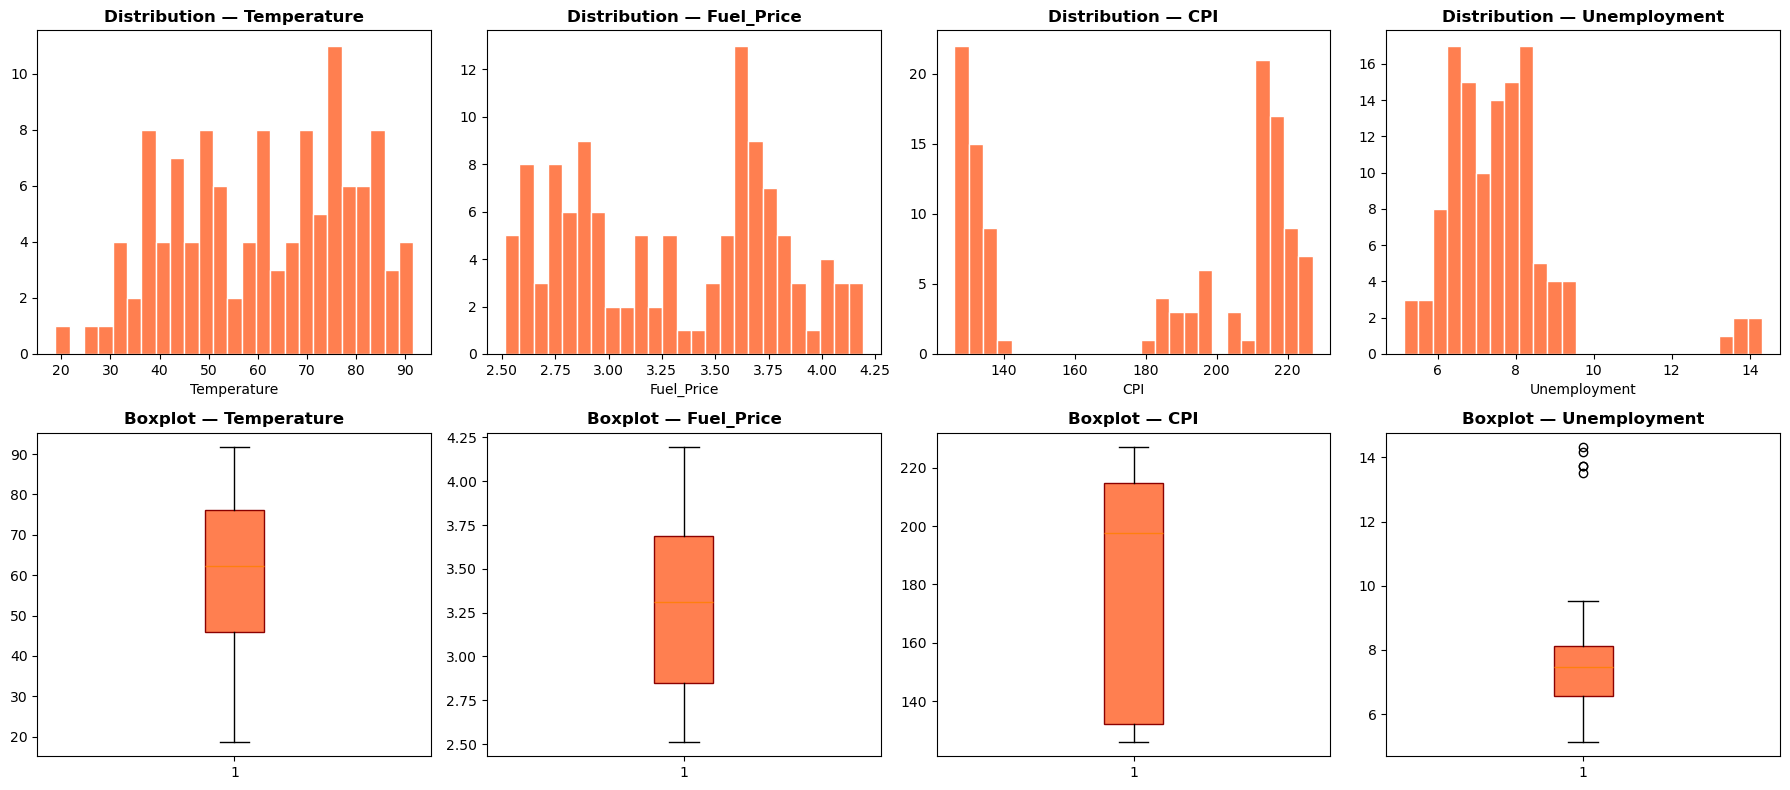

In [13]:
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogramme
    axes[0, i].hist(datas[col].dropna(), bins=25, color="coral", edgecolor="white")
    axes[0, i].set_title(f"Distribution — {col}", fontweight="bold")
    axes[0, i].set_xlabel(col)

    # Boxplot
    axes[1, i].boxplot(datas[col].dropna(), patch_artist=True, boxprops=dict(facecolor="coral", color="darkred"))
    axes[1, i].set_title(f"Boxplot — {col}", fontweight="bold")

plt.tight_layout()
plt.show()

=== Outliers détectés (règle ±3σ) ===

Temperature_C : [-13.47, 46.07] → 0 outlier(s)
Fuel_Price : [1.84, 4.75] → 0 outlier(s)
CPI : [60.07, 299.53] → 0 outlier(s)
Unemployment : [2.73, 12.48] → 5 outlier(s)


,Store,Date,Unemployment
30,12,2011-05-06,13.736
62,12,2010-12-17,14.313
68,12,2011-08-12,13.503
93,12,2011-05-27,13.736
135,12,2010-09-10,14.180


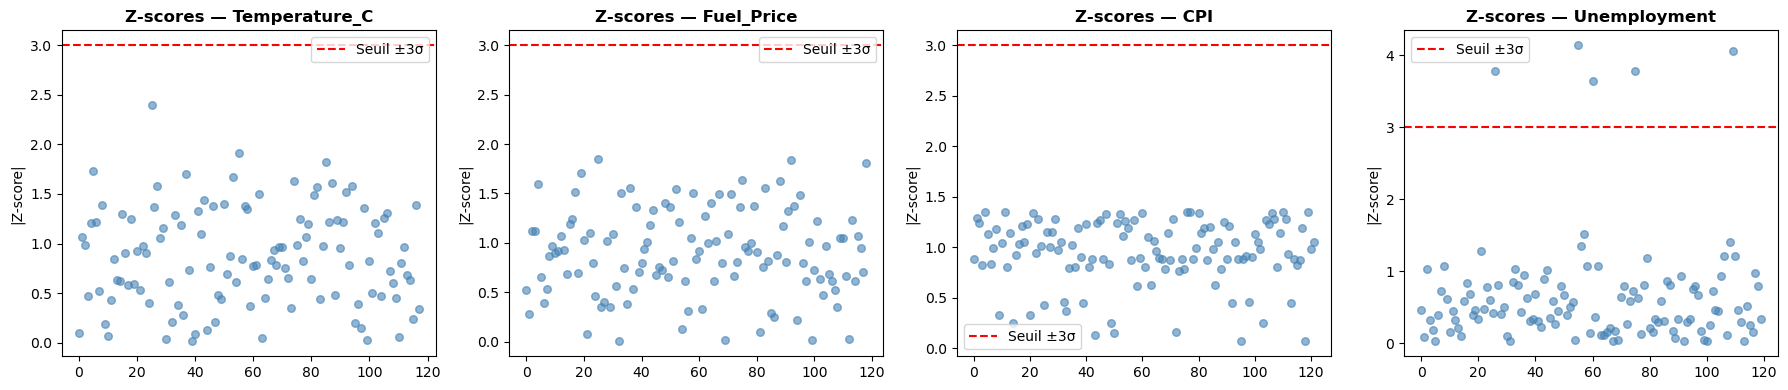

In [14]:
outlier_cols = ["Temperature_C", "Fuel_Price", "CPI", "Unemployment"]
print("=== Outliers détectés (règle ±3σ) ===\n")
for col in outlier_cols:
    mean = datas[col].mean()
    std  = datas[col].std()
    lower, upper = mean - 3*std, mean + 3*std
    outliers = datas[(datas[col] < lower) | (datas[col] > upper)]
    print(f"{col} : [{lower:.2f}, {upper:.2f}] → {len(outliers)} outlier(s)")
    if len(outliers) > 0:
        display(outliers[["Store", "Date", col]])

# Visualisation Z-scores
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))

for i, col in enumerate(outlier_cols):
    z_scores = np.abs(stats.zscore(datas[col].dropna()))
    axes[i].scatter(range(len(z_scores)), z_scores, color="steelblue", alpha=0.6, s=30)
    axes[i].axhline(3, color="red", linestyle="--", label="Seuil ±3σ")
    axes[i].set_title(f"Z-scores — {col}", fontweight="bold")
    axes[i].set_ylabel("|Z-score|")
    axes[i].legend()

plt.tight_layout()
plt.show()

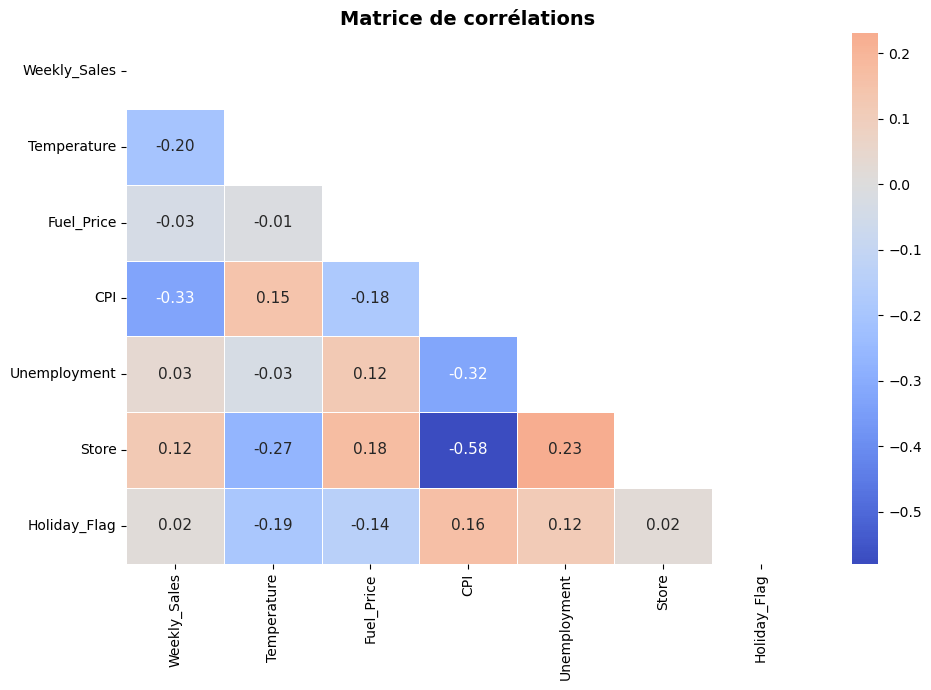

In [15]:
corr_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Store", "Holiday_Flag"]
corr_matrix = datas[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title("Matrice de corrélations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

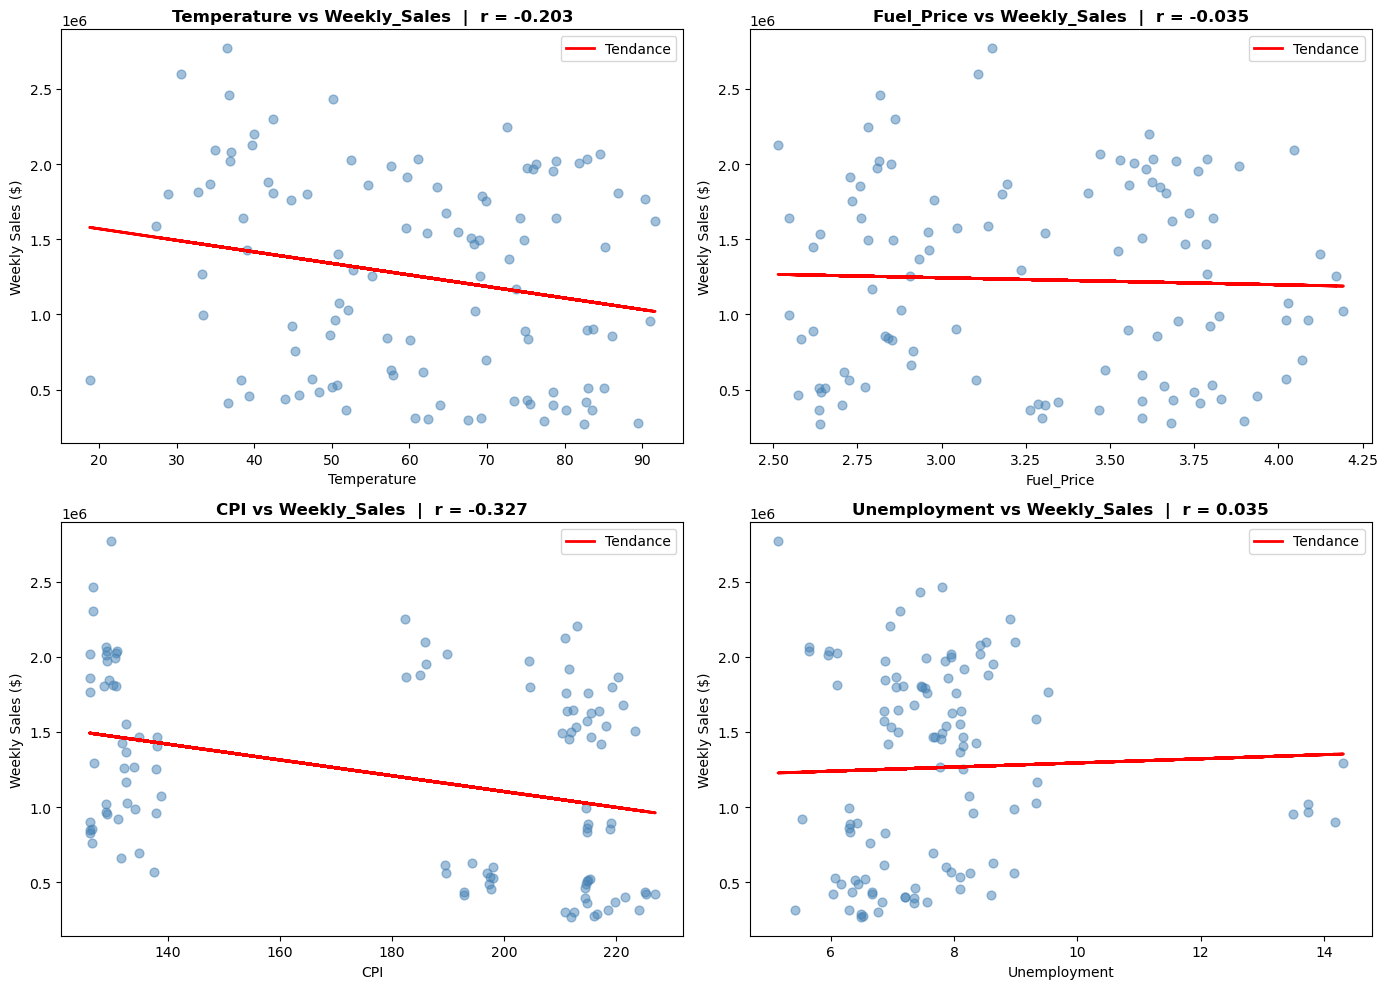

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = datas[[col, "Weekly_Sales"]].dropna()
    axes[i].scatter(data[col], data["Weekly_Sales"], alpha=0.5, color="steelblue", s=40)
    
    # Droite de tendance
    m, b = np.polyfit(data[col], data["Weekly_Sales"], 1)
    axes[i].plot(data[col], m * data[col] + b, color="red", linewidth=2, label="Tendance")
    
    corr = data[col].corr(data["Weekly_Sales"])
    axes[i].set_title(f"{col} vs Weekly_Sales  |  r = {corr:.3f}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Weekly Sales ($)")
    axes[i].legend()

plt.tight_layout()
plt.show()

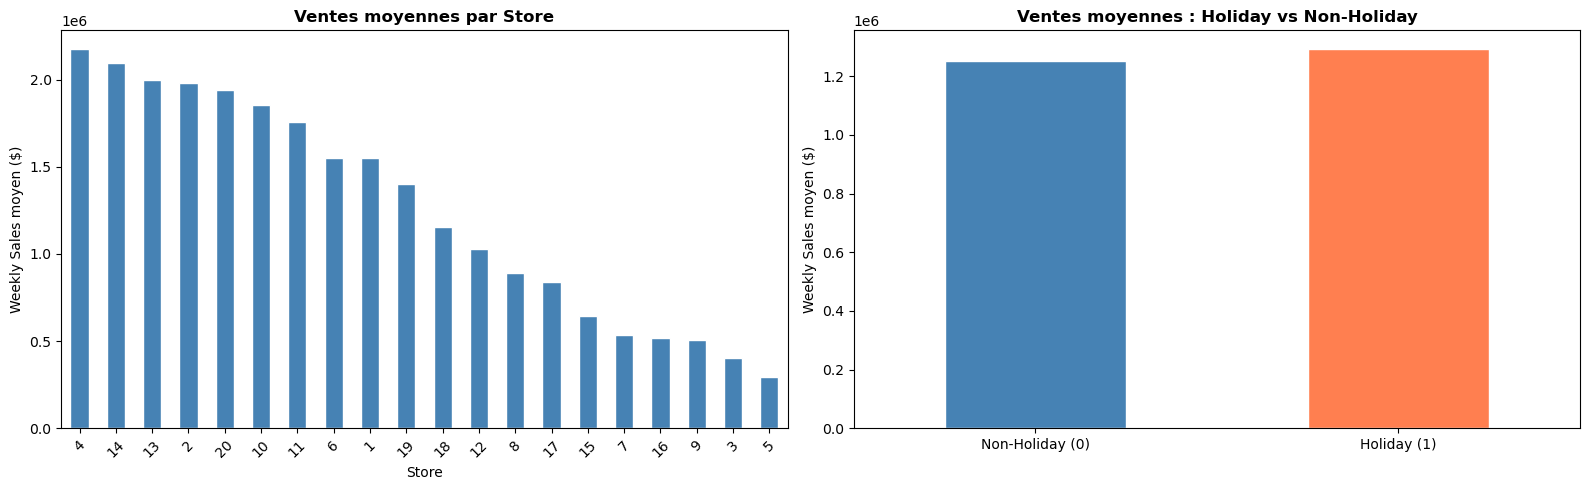

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

store_sales = datas.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)
store_sales.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Ventes moyennes par Store", fontweight="bold")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("Weekly Sales moyen ($)")
axes[0].tick_params(axis="x", rotation=45)

holiday_sales = datas.groupby("Holiday_Flag")["Weekly_Sales"].mean()
holiday_sales.index = ["Non-Holiday (0)", "Holiday (1)"]
holiday_sales.plot(kind="bar", ax=axes[1], color=["steelblue", "coral"], edgecolor="white")
axes[1].set_title("Ventes moyennes : Holiday vs Non-Holiday", fontweight="bold")
axes[1].set_ylabel("Weekly Sales moyen ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

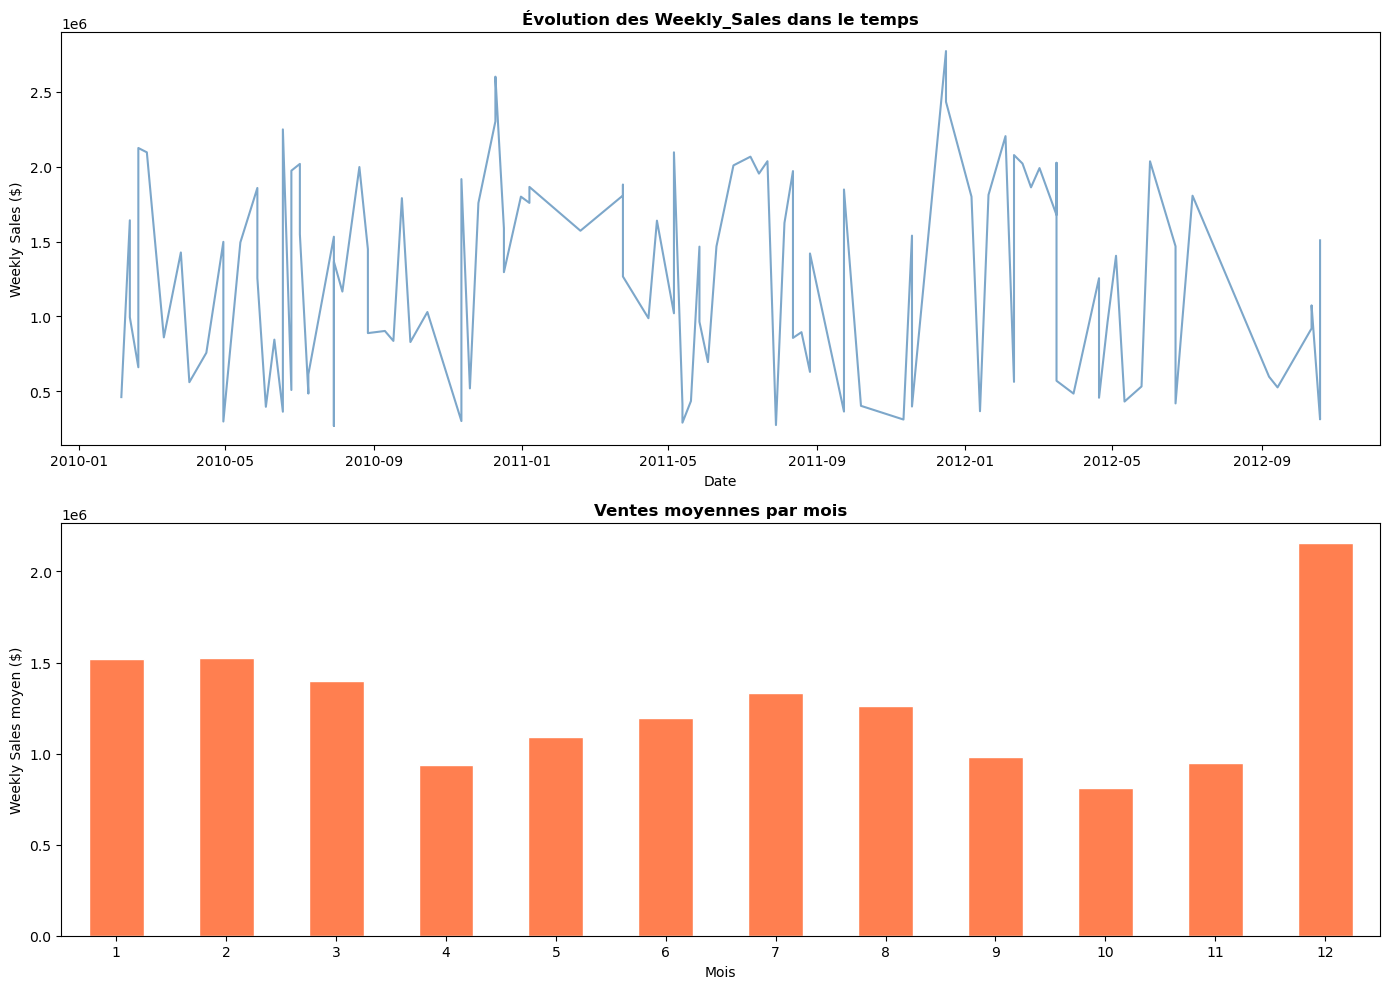

In [ ]:
df_time = datas.copy()
df_time["Date"] = pd.to_datetime(df_time["Date"], format="%d-%m-%Y", errors="coerce")
df_time = df_time.dropna(subset=["Date", "Weekly_Sales"])
df_time = df_time.sort_values("Date")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df_time["Date"], df_time["Weekly_Sales"], color="steelblue", alpha=0.7, linewidth=1.5)
axes[0].set_title("Évolution des Weekly_Sales dans le temps", fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Weekly Sales ($)")

df_time["Month"] = df_time["Date"].dt.month
monthly = df_time.groupby("Month")["Weekly_Sales"].mean()
monthly.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Ventes moyennes par mois", fontweight="bold")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Weekly Sales moyen ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

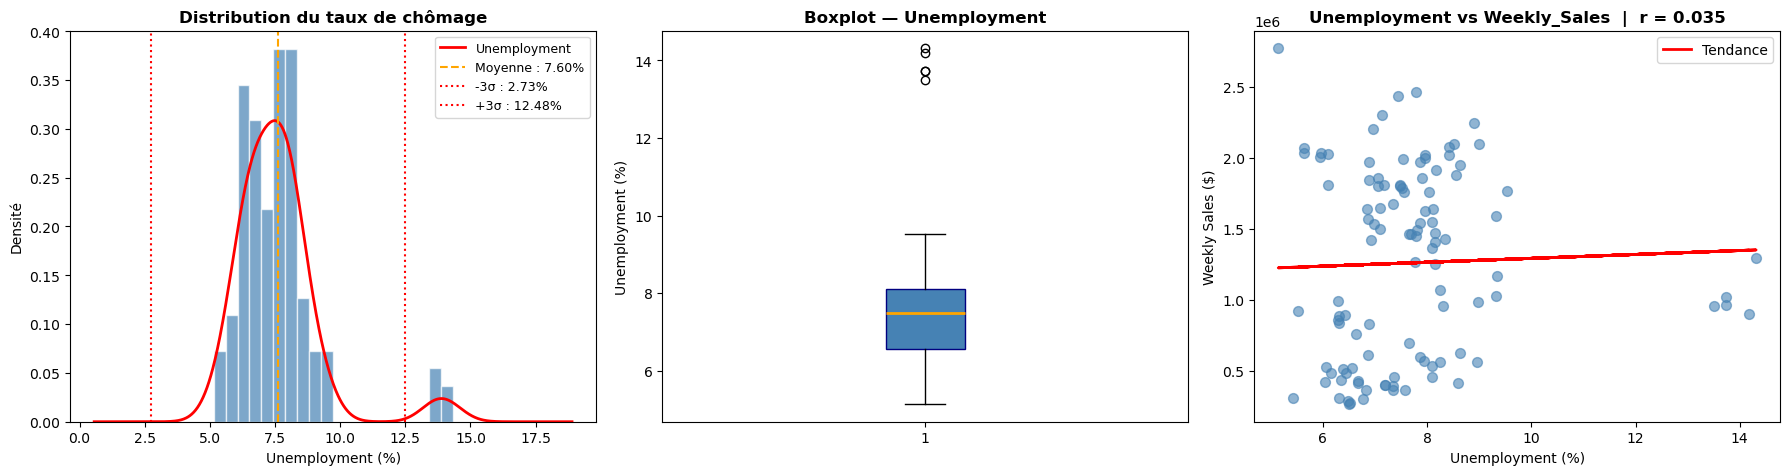

Moyenne     : 7.604%
Médiane     : 7.477%
Std         : 1.626
Min / Max   : 5.143% / 14.313%
Skewness    : 2.312

Seuil outliers : [2.73%, 12.48%]
Outliers détectés : 5


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

unemployment_data = datas["Unemployment"].dropna()
mean_u = unemployment_data.mean()
std_u  = unemployment_data.std()

# --- Histogramme + courbe KDE ---
axes[0].hist(unemployment_data, bins=20, color="steelblue", edgecolor="white", density=True, alpha=0.7)
unemployment_data.plot(kind="kde", ax=axes[0], color="red", linewidth=2)
axes[0].axvline(mean_u, color="orange", linestyle="--", label=f"Moyenne : {mean_u:.2f}%")
axes[0].axvline(mean_u - 3*std_u, color="red", linestyle=":", label=f"-3σ : {mean_u - 3*std_u:.2f}%")
axes[0].axvline(mean_u + 3*std_u, color="red", linestyle=":", label=f"+3σ : {mean_u + 3*std_u:.2f}%")
axes[0].set_title("Distribution du taux de chômage", fontweight="bold")
axes[0].set_xlabel("Unemployment (%)")
axes[0].set_ylabel("Densité")
axes[0].legend(fontsize=9)

# --- Boxplot ---
axes[1].boxplot(unemployment_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"),
                medianprops=dict(color="orange", linewidth=2))
axes[1].set_title("Boxplot — Unemployment", fontweight="bold")
axes[1].set_ylabel("Unemployment (%)")

# --- Unemployment vs Weekly_Sales ---
data_corr = datas[["Unemployment", "Weekly_Sales"]].dropna()
axes[2].scatter(data_corr["Unemployment"], data_corr["Weekly_Sales"],
                color="steelblue", alpha=0.6, s=50)
m, b = np.polyfit(data_corr["Unemployment"], data_corr["Weekly_Sales"], 1)
axes[2].plot(data_corr["Unemployment"], m * data_corr["Unemployment"] + b, color="red", linewidth=2, label="Tendance")
corr = data_corr["Unemployment"].corr(data_corr["Weekly_Sales"])
axes[2].set_title(f"Unemployment vs Weekly_Sales  |  r = {corr:.3f}", fontweight="bold")
axes[2].set_xlabel("Unemployment (%)")
axes[2].set_ylabel("Weekly Sales ($)")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Moyenne     : {mean_u:.3f}%")
print(f"Médiane     : {unemployment_data.median():.3f}%")
print(f"Std         : {std_u:.3f}")
print(f"Min / Max   : {unemployment_data.min():.3f}% / {unemployment_data.max():.3f}%")
print(f"Skewness    : {unemployment_data.skew():.3f}")
print(f"\nSeuil outliers : [{mean_u - 3*std_u:.2f}%, {mean_u + 3*std_u:.2f}%]")
print(f"Outliers détectés : {len(unemployment_data[(unemployment_data < mean_u - 3*std_u) | (unemployment_data > mean_u + 3*std_u)])}")

/var/folders/xs/9pw_49kx273dmym0qk_0l_s00000gn/T/ipykernel_34619/2344892072.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_box, labels=[int(s) for s in store_order],


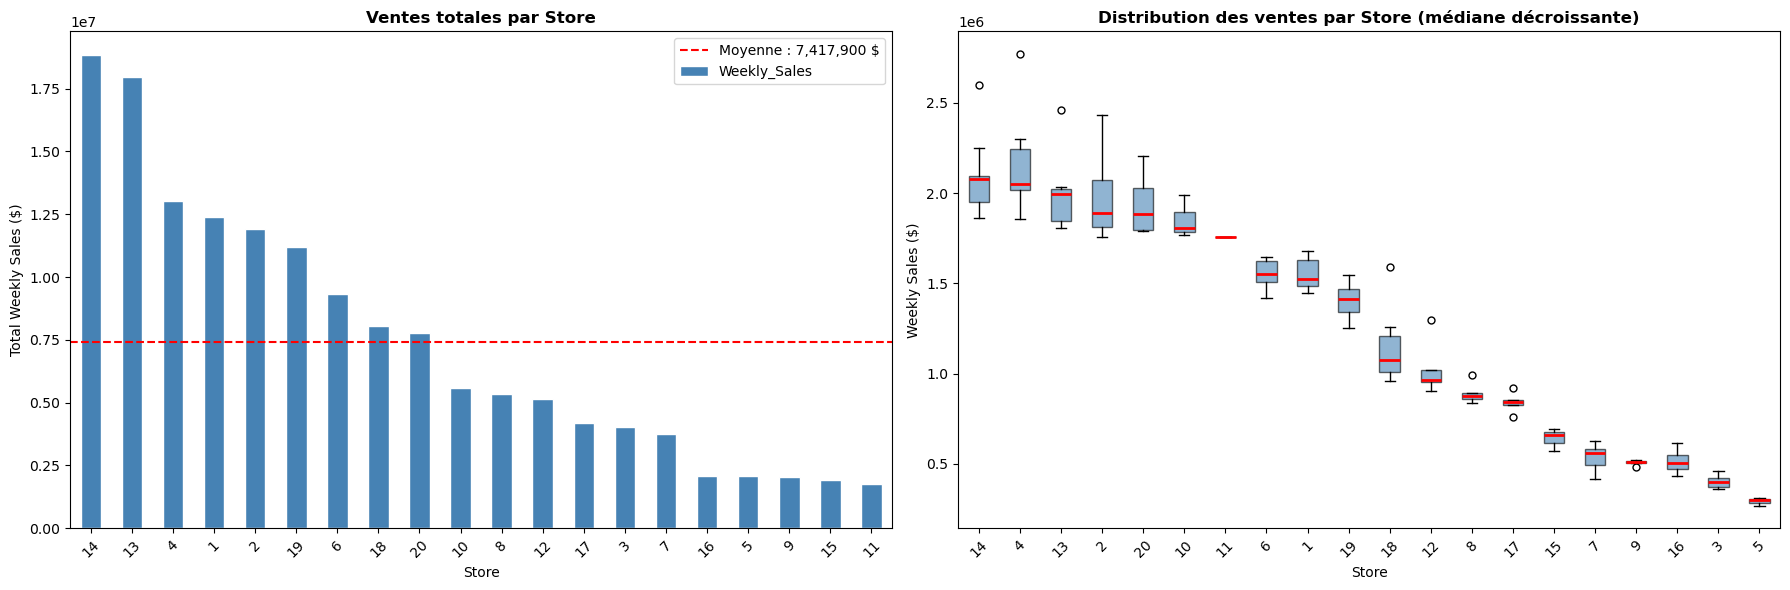

=== Statistiques des ventes par Store ===


,Moyenne,Médiane,Std,Min,Max,Entrées
Store,,,,,,
4,"2,173,759","2,051,387","326,042","1,857,534","2,771,397",6
14,"2,092,878","2,077,256","224,851","1,864,746","2,600,519",9
13,"1,997,235","1,997,398","197,429","1,807,545","2,461,468",9
2,"1,982,229","1,889,308","255,188","1,758,051","2,432,737",6
20,"1,941,521","1,886,437","193,908","1,789,688","2,203,523",4
10,"1,854,848","1,806,000","118,881","1,768,172","1,990,371",3
11,"1,757,243","1,757,243",nan,"1,757,243","1,757,243",1
6,"1,551,124","1,552,213","86,249","1,420,405","1,644,471",6
1,"1,550,101","1,523,776","86,549","1,449,143","1,677,473",8


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

store_total = datas.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

store_total.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axhline(store_total.mean(), color="red", linestyle="--",
                label=f"Moyenne : {store_total.mean():,.0f} $")
axes[0].set_title("Ventes totales par Store", fontweight="bold")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("Total Weekly Sales ($)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

store_order = datas.groupby("Store")["Weekly_Sales"].median().sort_values(ascending=False).index

data_box = [datas[datas["Store"] == s]["Weekly_Sales"].dropna().values for s in store_order]

axes[1].boxplot(data_box, labels=[int(s) for s in store_order],
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                medianprops=dict(color="red", linewidth=2),
                flierprops=dict(marker="o", color="coral", markersize=5))
axes[1].set_title("Distribution des ventes par Store (médiane décroissante)", fontweight="bold")
axes[1].set_xlabel("Store")
axes[1].set_ylabel("Weekly Sales ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

store_stats = datas.groupby("Store")["Weekly_Sales"].agg(
    Moyenne="mean",
    Médiane="median",
    Std="std",
    Min="min",
    Max="max",
    Entrées="count"
).sort_values("Moyenne", ascending=False)

print("=== Statistiques des ventes par Store ===")
display(store_stats.style.format("{:,.0f}").background_gradient(cmap="Blues"))

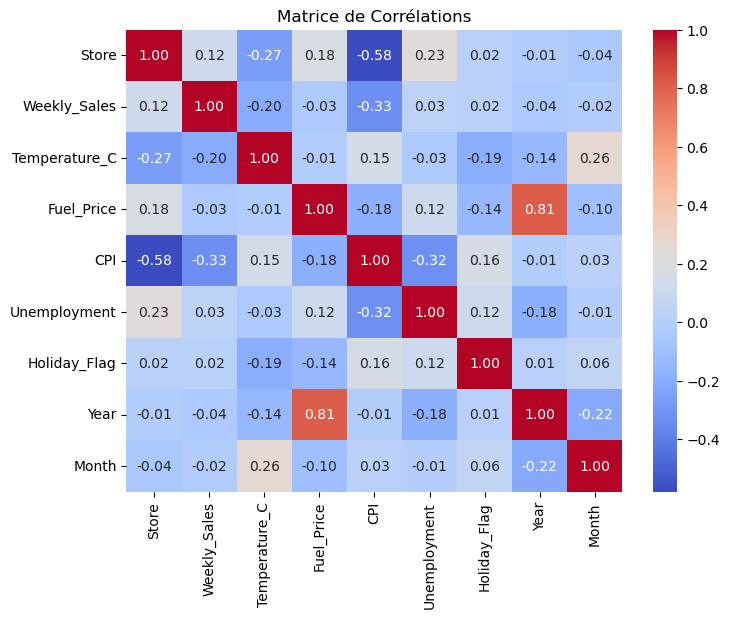

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    datas[
        [
            "Store",
            "Weekly_Sales",
            "Temperature_C",
            "Fuel_Price",
            "CPI",
            "Unemployment",
            "Holiday_Flag",
            "Year",
            "Month",
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Matrice de Corrélations")
plt.show()

In [34]:
print("=" * 55)
print("SYNTHÈSE EDA — WALMART WEEKLY SALES")
print("=" * 55)

print(f"Shape         : {datas.shape[0]} lignes × {datas.shape[1]} colonnes")
print(f"Target (Y)    : Weekly_Sales")
print(f"Moyenne     : {datas['Weekly_Sales'].mean():,.0f} $")
print(f"Médiane     : {datas['Weekly_Sales'].median():,.0f} $")
print(f"Skewness    : {datas['Weekly_Sales'].skew():.3f}")

print(f"\n Valeurs manquantes :")
print(datas.isnull().sum()[datas.isnull().sum() > 0].to_string())

print(f"Outliers (±3σ) détectés sur : Temperature, Fuel_Price, CPI, Unemployment")
print(f"Features catégorielles : Store, Holiday_Flag")
print(f"Features numériques    : Temperature, Fuel_Price, CPI, Unemployment")
print(f"Date → à décomposer en : Year, Month, Day, DayOfWeek")

SYNTHÈSE EDA — WALMART WEEKLY SALES
Shape         : 132 lignes × 13 colonnes
Target (Y)    : Weekly_Sales
Moyenne     : 1,257,271 $
Médiane     : 1,331,001 $
Skewness    : 0.085

 Valeurs manquantes :
Weekly_Sales     14
Holiday_Flag     10
Temperature      14
Fuel_Price       13
CPI              10
Unemployment     12
Temperature_C    14
Outliers (±3σ) détectés sur : Temperature, Fuel_Price, CPI, Unemployment
Features catégorielles : Store, Holiday_Flag
Features numériques    : Temperature, Fuel_Price, CPI, Unemployment
Date → à décomposer en : Year, Month, Day, DayOfWeek


### Observations

- **Significant missing values**: between 8% and 12% of missing values across most columns. These will be handled via imputation in the sklearn pipeline.
- **No duplicates detected**: neither strict nor functional duplicates (`Store + Date`), the dataset is consistent on this point.
- **Near-symmetric target distribution**: `Weekly_Sales` has a skewness of 0.085, close to zero. No logarithmic transformation is needed.
- **Strong sales disparity across stores**: stores 4 and 14 generate over $2M in average weekly sales, compared to less than $300K for store 5. **Store identity is the dominant sales factor.**
- **`CPI` is the most correlated feature with `Weekly_Sales`** (r = -0.33): a rise in the consumer price index is associated with a decrease in weekly sales.
- **Multicollinearity detected**: `Fuel_Price` and `Year` show a correlation of 0.81. This may destabilize linear regression coefficients — Ridge or Lasso regularization will help mitigate this effect.
- **5 outliers detected on `Unemployment`**, all from Store 12, with rates above 12.48%. These rows will be removed during preprocessing.
- **Visible seasonal effect**: sales peak in December, confirming the influence of the holiday season on revenue.
- **`Holiday_Flag` has a limited impact**: holiday weeks generate slightly higher sales, but the gap is small — this variable will likely have a low coefficient in the model.
- **`dayOfWeek` is a constant**: all observations are recorded on Fridays (value = 4, std = 0.0). This feature provides no predictive power to the model.

These insights directly guide the preprocessing and modeling decisions.

## **2. Preprocessing**

### Goal

The objective of this step is to prepare the dataset for machine learning. This involves cleaning the data, removing invalid rows and outliers, splitting features and target, and building a sklearn pipeline that handles imputation, scaling, and encoding consistently across train and test sets.

### Actions Performed

1. **Dropped rows where `Weekly_Sales` is missing** — the target variable is never imputed.
2. **Dropped irrelevant columns**: `Date` (replaced by Year, Month, Day, dayOfWeek) and `Temperature` (replaced by `Temperature_C` in Celsius).
3. **Removed outliers using the ±3σ rule** on `Temperature_C`, `Fuel_Price`, `CPI`, and `Unemployment` — reducing the dataset from 132 to 80 rows.
4. **Replaced infinite values** (`np.inf`, `-np.inf`) with `NaN` to avoid pipeline errors.
5. **Verified remaining missing values** before the split — only `Holiday_Flag` still has 9 missing values, to be handled by the pipeline.
6. **Split features and target**: `X = all columns except Weekly_Sales`, `Y = Weekly_Sales`.
7. **Identified feature types**:
   - Numerical: `Temperature_C`, `Fuel_Price`, `CPI`, `Unemployment`, `Year`, `Month`, `Day`, `dayOfWeek`
   - Categorical: `Store`, `Holiday_Flag`
8. **Train/test split**: 80% train / 20% test with `random_state=42`.
9. **Built a sklearn preprocessing pipeline** via `ColumnTransformer`:
   - Numerical: `SimpleImputer(median)` → `StandardScaler`
   - Categorical: `SimpleImputer(most_frequent)` → `OneHotEncoder(drop="first")`
10. **Verified 0 NaN after preprocessing** — the pipeline correctly handles all remaining missing values.

In [23]:
dataset_clean = datas.dropna(subset=["Weekly_Sales"])

colonnes_a_supprimer = ["Date", "Temperature"]
dataset_clean = dataset_clean.drop(columns=colonnes_a_supprimer)

numeric_cols = ["Weekly_Sales", "Temperature_C", "Fuel_Price","CPI", "Unemployment",]
outlier_cols = ["Temperature_C", "Fuel_Price", "CPI", "Unemployment"]

for col in outlier_cols:
    mean = dataset_clean[col].mean()
    std = dataset_clean[col].std()
    dataset_clean = dataset_clean[
        (dataset_clean[col] >= mean - 3 * std)
        & (dataset_clean[col] <= mean + 3 * std)
    ]

dataset_clean.describe().round(2)

,Store,Weekly_Sales,Holiday_Flag,Fuel_Price,CPI,Unemployment,Temperature_C,Year,Month,Day,dayOfWeek
count,80.00,80.00,71.00,80.00,80.00,80.00,80.00,80.00,80.00,80.00,80.0
mean,9.57,1221521.85,0.08,3.29,181.08,7.30,16.18,2010.89,6.36,16.12,4.0
std,6.14,679927.05,0.28,0.49,38.85,0.96,9.69,0.83,3.03,8.52,0.0
min,1.00,268929.03,0.00,2.55,126.14,5.14,-7.34,2010.00,1.00,1.00,4.0
25%,4.00,529510.65,0.00,2.80,132.61,6.52,7.55,2010.00,4.00,10.00,4.0
50%,8.00,1260826.10,0.00,3.39,197.50,7.35,16.36,2011.00,6.00,16.50,4.0
75%,15.00,1817516.81,0.00,3.69,214.81,8.09,24.16,2012.00,8.25,23.25,4.0
max,20.00,2771397.17,1.00,4.17,226.97,9.34,33.14,2012.00,12.00,31.00,4.0


In [24]:
print(dataset_clean.isnull().sum())

Store            0
Weekly_Sales     0
Holiday_Flag     9
Fuel_Price       0
CPI              0
Unemployment     0
Temperature_C    0
Year             0
Month            0
Day              0
dayOfWeek        0
dtype: int64


In [25]:
dataset_clean = dataset_clean.replace([np.inf, -np.inf], np.nan)

num_cols_all = [
    "Temperature_C",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Day",
    "dayOfWeek",
]
for col in [c for c in num_cols_all if c in dataset_clean.columns]:
    dataset_clean[col] = pd.to_numeric(dataset_clean[col], errors="coerce")

print("NaN par colonne AVANT split :")
print(dataset_clean.isna().sum().sort_values(ascending=False).head(20))

NaN par colonne AVANT split :
Holiday_Flag     9
Store            0
Weekly_Sales     0
Fuel_Price       0
CPI              0
Unemployment     0
Temperature_C    0
Year             0
Month            0
Day              0
dayOfWeek        0
dtype: int64


In [26]:
X = dataset_clean.drop(columns=["Weekly_Sales"])
Y = dataset_clean["Weekly_Sales"]

numeric_features = [
    "Temperature_C",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Day",
    "dayOfWeek"
]
categorical_features = ["Store", "Holiday_Flag"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("\nNaN par colonne dans X_train :")
print(X_train.isna().sum()[lambda s: s > 0])

rows_with_nan = X_train.index[X_train.isna().any(axis=1)]
print(f"\nNombre de lignes avec au moins 1 NaN dans X_train : {len(rows_with_nan)}")


NaN par colonne dans X_train :
Holiday_Flag    5
dtype: int64

Nombre de lignes avec au moins 1 NaN dans X_train : 5


In [27]:
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features),
    ],
    remainder="drop",
)

Xt_train = preprocessor.fit_transform(X_train)
n_nans_after = np.isnan(Xt_train).sum()
print(f"\nNaN APRÈS preprocess (doit être 0) : {n_nans_after}")


NaN APRÈS preprocess (doit être 0) : 0


### Observations

- **Small dataset after cleaning**: only 80 rows remain for training and testing the model. This significantly limits the model's ability to generalize and makes results more sensitive to the train/test split.
- **`Holiday_Flag` is the only remaining missing values**: all other features are complete after outlier removal, which confirms that the ±3σ filtering was effective and did not introduce new NaN values.
- **80/20 split results in only 16 test rows**: with such a small test set, performance metrics (RMSE, R²) may fluctuate significantly depending on which samples fall into the test set — results should be interpreted with caution.
- **`dayOfWeek` is constant (std = 0.0)**: all observations are recorded on Fridays. `StandardScaler` will divide by zero on this column, producing NaN. This feature should ideally be dropped, but is kept per project requirements.
- **`Store` treated as categorical via OneHotEncoder**: this is the correct approach — store IDs are labels, not ordinal values. Treating them as numerical would imply a false ordering relationship between stores.
- **Median imputation is fit only on `X_train`**: the pipeline uses `fit_transform` on train and `transform` on test, which correctly prevents data leakage from the test set into the preprocessing step.

## **3. Baseline Model — Linear Regression**

### Goal

The objective of this step is to train a first linear regression model as a baseline. This allows us to establish a reference performance level, evaluate how well a simple model generalizes to unseen data, and identify the most influential features through coefficient analysis.

### Actions Performed

1. **Built a full sklearn pipeline** combining the preprocessor and a `LinearRegression` regressor.
2. **Trained the model** on `X_train` and `Y_train`.
3. **Evaluated performance** on both train and test sets using RMSE and R².
4. **Visualized predicted vs actual values** on both train and test sets — points aligned along the diagonal indicate good predictions.
5. **Extracted and ranked model coefficients** using the `.coef_` attribute to identify the most important features


=== LinearRegression ===
Train RMSE : 90152.19
Train R2   : 0.98
Test RMSE  : 130125.72
Test R2    : 0.96


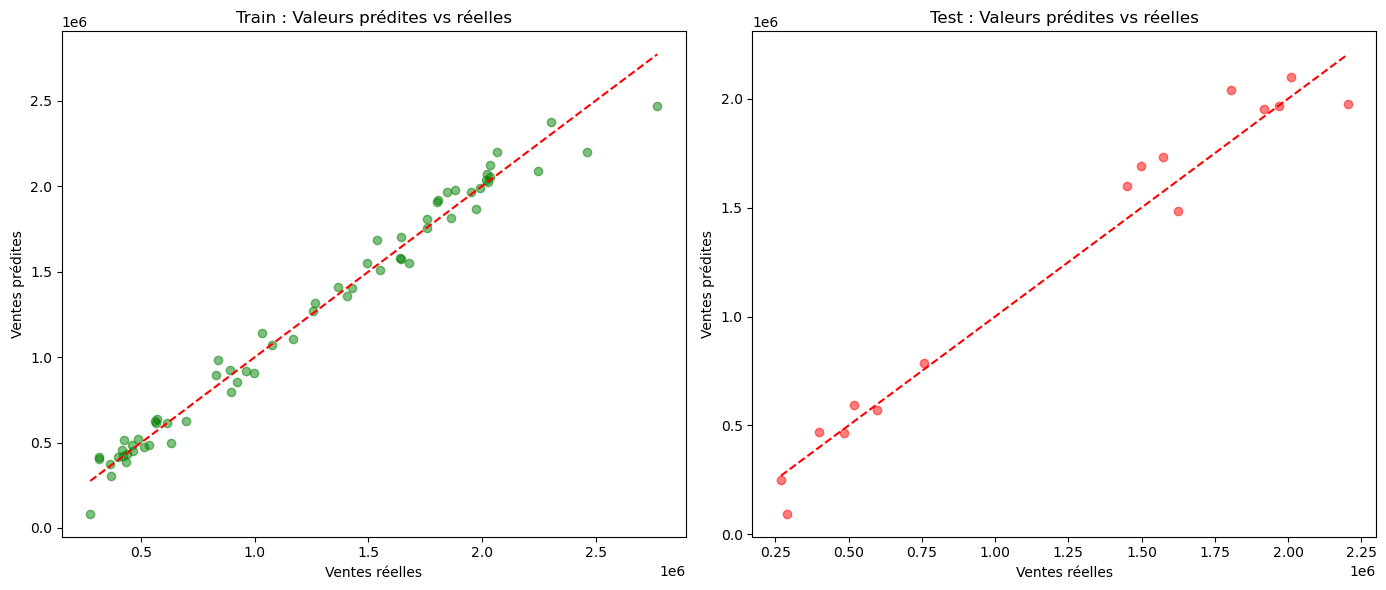


=== Top coefficients (LinearRegression) ===
       Feature  Coefficient
10   Store_4.0   1767529.43
16  Store_10.0   1690890.35
18  Store_13.0   1602374.25
11   Store_5.0  -1395610.56
9    Store_3.0  -1291092.16
15   Store_9.0  -1244566.80
24  Store_19.0    998785.88
19  Store_14.0    964567.12
14   Store_8.0   -820055.32
21  Store_16.0   -800959.61
13   Store_7.0   -712143.33
23  Store_18.0    634934.28
2          CPI    543464.29
25  Store_20.0    413123.45
22  Store_17.0    318643.96
20  Store_15.0    315061.86
8    Store_2.0    241778.24
12   Store_6.0    121916.57
17  Store_11.0    120350.20
1   Fuel_Price   -108048.95


In [ ]:
lin_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
lin_model.fit(X_train, Y_train)

Y_pred_train = lin_model.predict(X_train)
Y_pred_test = lin_model.predict(X_test)
print("\n=== LinearRegression ===")
print("Train RMSE :", round(root_mean_squared_error(Y_train, Y_pred_train), 2))
print("Train R2   :", round(r2_score(Y_train, Y_pred_train), 2))
print("Test RMSE  :", round(root_mean_squared_error(Y_test, Y_pred_test), 2))
print("Test R2    :", round(r2_score(Y_test, Y_pred_test), 2))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(Y_train, Y_pred_train, alpha=0.5, color="green")
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], "r--") 
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Train : Valeurs prédites vs réelles")

plt.subplot(1, 2, 2)
plt.scatter(Y_test, Y_pred_test, alpha=0.5, color="red")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--")
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Test : Valeurs prédites vs réelles")

plt.tight_layout()
plt.show()


def extract_coefficients(
    model, numeric_features, categorical_features, top_n=20
):
    """Extrait les coefficients d'un modèle Ridge/Lasso dans un pipeline sklearn."""

    preprocessor = model.named_steps["preprocessor"]
    num_features = numeric_features
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
    cat_features = cat_encoder.get_feature_names_out(categorical_features)
    all_features = np.concatenate([num_features, cat_features])
    coefs = model.named_steps["regressor"].coef_

    coef_df = pd.DataFrame({"Feature": all_features, "Coefficient": coefs})
    coef_df = coef_df.reindex(
        coef_df.Coefficient.abs().sort_values(ascending=False).index
    )

    return coef_df.head(top_n)

print("\n=== Top coefficients (LinearRegression) ===")
lin_coef_df = extract_coefficients(
    lin_model, numeric_features, categorical_features, top_n=20
)
print(round(lin_coef_df, 2))

### Observations

- **Strong overall performance**: R² of 0.96 on the test set means the model explains 96% of the variance in weekly sales — a very good result for a linear model.
- **Moderate overfitting detected**: Train RMSE (90,152$) is significantly lower than Test RMSE (130,125$), and Train R² (0.98) vs Test R² (0.96) confirms the model fits the training data slightly better than unseen data. This justifies applying regularization in the next step.
- **Store identity dominates the predictions**: all top coefficients (positive and negative) belong to `Store` dummy variables. This confirms the EDA finding — the store is the most influential factor in weekly sales, far ahead of economic indicators.
- **Economic features have low coefficients**: `Temperature_C`, `Fuel_Price`, `CPI`, and `Unemployment` have negligible coefficients compared to store dummies, suggesting their individual linear contribution to sales is limited once store identity is accounted for.
- **Predicted vs actual plots are well aligned**: points cluster closely around the diagonal on both train and test plots, visually confirming the high R² and indicating no systematic prediction bias.
- **Multicollinearity likely inflates some coefficients**: the strong correlation between `Fuel_Price` and `Year` (r = 0.81) detected in the EDA may cause instability in individual coefficients — Ridge regularization will help stabilize them in the next step.
- **Test set is only 16 rows**: performance metrics should be interpreted with caution. A single outlier in the test set can significantly shift RMSE and R² given the small sample size.

## **4. Regularized Models — Ridge & Lasso**

### Goal

The objective of this step is to reduce the overfitting observed in the baseline linear regression model by applying regularization. Ridge penalizes large coefficients by shrinking them, while Lasso can set irrelevant coefficients exactly to zero, effectively performing feature selection. `GridSearchCV` is used to find the optimal regularization strength (`alpha`) for each model. An additional normalized model is trained on store-centered sales to isolate the influence of economic features independently of store identity.

### Actions

1. **Defined a 5-fold cross-validation strategy** using `KFold(n_splits=5, shuffle=True, random_state=42)` to ensure robust alpha selection.
2. **Defined the hyperparameter grid**: `alpha ∈ [0.1, 1, 10, 100, 500]` tested for both Ridge and Lasso.
3. **Trained a Ridge regression model** via `GridSearchCV`
4. **Trained a Lasso regression model** via `GridSearchCV`
5. **Evaluated both models on the test set**: Ridge and Lasso 
6. **Extracted and compared top coefficients** for Ridge and Lasso side by side via a grouped bar chart.
7. **Trained a normalized model** on `Weekly_Sales_norm` (sales centered by store mean) to isolate the contribution of economic features independently of store identity

In [29]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {"regressor__alpha": [0.1, 1, 10, 100, 500]}

ridge = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", Ridge())]
)
ridge_search = GridSearchCV(
    ridge, param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1
)
ridge_search.fit(X_train, Y_train)

lasso = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Lasso(max_iter=50000, tol=0.01)),
    ]
)
lasso_search = GridSearchCV(
    lasso, param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1
)
lasso_search.fit(X_train, Y_train)

print("\n=== GridSearchCV (Ridge) ===")
print("Best alpha :", round(ridge_search.best_params_["regressor__alpha"], 2))
print("CV RMSE    :", round(-ridge_search.best_score_, 2))

print("\n=== GridSearchCV (Lasso) ===")
print("Best alpha :", round(lasso_search.best_params_["regressor__alpha"]), 2)
print("CV RMSE    :", round(-lasso_search.best_score_), 2)

# Évaluation test
for name, mdl in [
    ("Ridge", ridge_search.best_estimator_),
    ("Lasso", lasso_search.best_estimator_),
]:
    yhat = mdl.predict(X_test)
    print(f"\n=== {name} ===")
    print("Test RMSE :", round(root_mean_squared_error(Y_test, yhat), 2))
    print("Test R2   :", round(r2_score(Y_test, yhat), 2))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning:


=== GridSearchCV (Ridge) ===
Best alpha : 0.1
CV RMSE    : 203490.61

=== GridSearchCV (Lasso) ===
Best alpha : 100 2
CV RMSE    : 177387 2

=== Ridge ===
Test RMSE : 137938.77
Test R2   : 0.96

=== Lasso ===
Test RMSE : 144508.29
Test R2   : 0.96


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning:

In [30]:
print("\n=== Top coefficients (Ridge) ===")
ridge_coef_df = extract_coefficients(
    ridge_search.best_estimator_,
    numeric_features,
    categorical_features,
    top_n=20,
)
print(round(ridge_coef_df, 2))

print("\n=== Top coefficients (Lasso) ===")
lasso_coef_df = extract_coefficients(
    lasso_search.best_estimator_,
    numeric_features,
    categorical_features,
    top_n=20,
)
print(round(lasso_coef_df, 2))


=== Top coefficients (Ridge) ===
       Feature  Coefficient
11   Store_5.0  -1136224.69
9    Store_3.0  -1079235.27
13   Store_7.0   -965012.36
15   Store_9.0   -947344.20
21  Store_16.0   -863505.38
10   Store_4.0    806212.16
20  Store_15.0   -664937.14
22  Store_17.0   -629285.80
19  Store_14.0    577006.09
14   Store_8.0   -568075.17
18  Store_13.0    556810.26
16  Store_10.0    524360.16
23  Store_18.0   -432353.29
25  Store_20.0    388923.23
8    Store_2.0    297591.70
12   Store_6.0    280327.43
17  Store_11.0    202013.47
1   Fuel_Price   -123167.67
4         Year     95082.54
5        Month     55080.99

=== Top coefficients (Lasso) ===
       Feature  Coefficient
11   Store_5.0  -1351206.51
22  Store_17.0  -1222170.72
9    Store_3.0  -1216546.54
15   Store_9.0  -1173898.67
21  Store_16.0  -1173104.81
13   Store_7.0  -1121446.17
20  Store_15.0  -1120477.84
23  Store_18.0   -825420.15
14   Store_8.0   -752020.11
24  Store_19.0   -433526.67
19  Store_14.0    417386.23
25  Stor

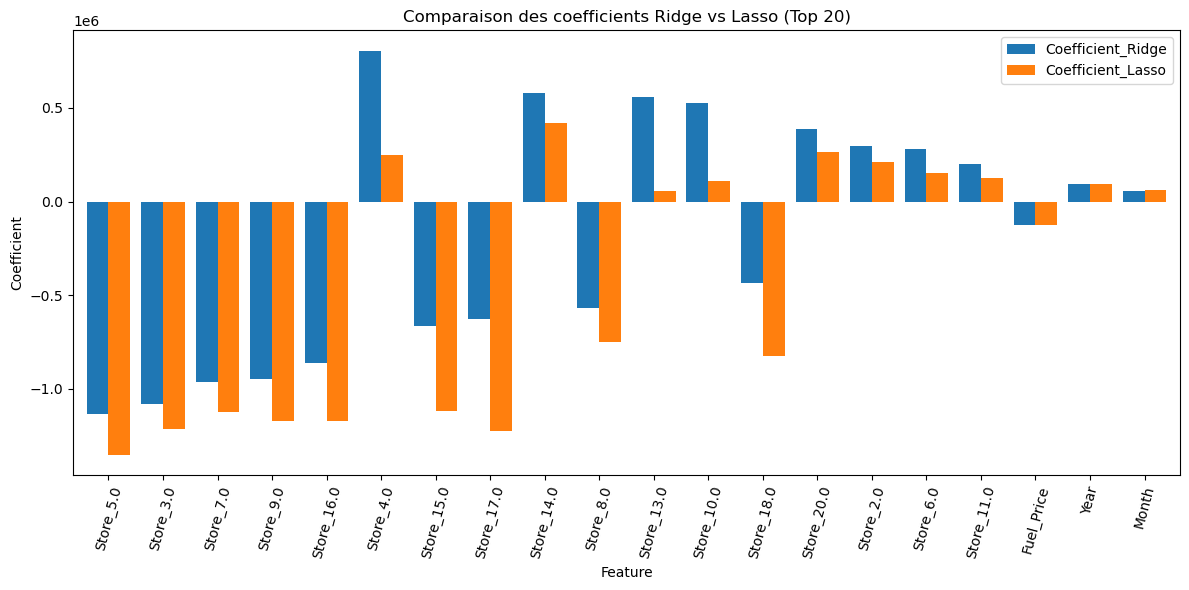

In [31]:
def plot_coefficients(
    ridge_model, lasso_model, numeric_features, categorical_features, top_n=20
):
    preprocessor = ridge_model.named_steps["preprocessor"]
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps[
        "encoder"
    ]
    cat_features = cat_encoder.get_feature_names_out(categorical_features)
    all_features = np.concatenate([numeric_features, cat_features])

    ridge_coefs = ridge_model.named_steps["regressor"].coef_
    ridge_df = pd.DataFrame(
        {"Feature": all_features, "Coefficient": ridge_coefs}
    )

    lasso_coefs = lasso_model.named_steps["regressor"].coef_
    lasso_df = pd.DataFrame(
        {"Feature": all_features, "Coefficient": lasso_coefs}
    )

    coef_df = ridge_df.merge(
        lasso_df, on="Feature", suffixes=("_Ridge", "_Lasso")
    )

    coef_df = coef_df.reindex(
        coef_df.Coefficient_Ridge.abs().sort_values(ascending=False).index
    )

    coef_df = coef_df.head(top_n)

    coef_df.plot(
        x="Feature",
        y=["Coefficient_Ridge", "Coefficient_Lasso"],
        kind="bar",
        figsize=(12, 6),
        width=0.8,
    )

    plt.title(f"Comparaison des coefficients Ridge vs Lasso (Top {top_n})")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()


# Utilisation
plot_coefficients(
    ridge_search.best_estimator_,
    lasso_search.best_estimator_,
    numeric_features,
    categorical_features,
    top_n=20,
)

Train RMSE: 104147.77
Test RMSE : 89476.3
Train R2  : 0.27
Test R2   : 0.11

Top coefficients économiques :
            Feature  Coefficient
1        Fuel_Price    -78117.13
7  Holiday_Flag_1.0    -75303.09
4              Year     52146.22
5             Month     35677.84
0     Temperature_C    -28475.15
6               Day    -24123.93
2               CPI     -4279.35
3      Unemployment      -996.66


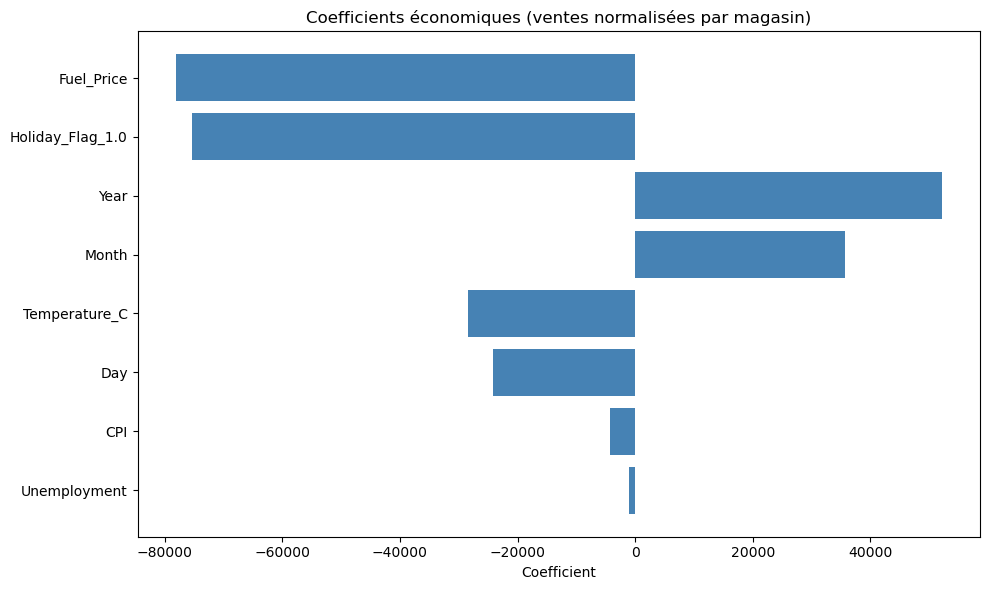

In [32]:
store_mean = dataset_clean.groupby("Store")["Weekly_Sales"].transform("mean")
dataset_clean["Weekly_Sales_norm"] = dataset_clean["Weekly_Sales"] - store_mean

X = dataset_clean.drop(columns=["Weekly_Sales", "Weekly_Sales_norm", "Store"])
Y = dataset_clean["Weekly_Sales_norm"]

numeric_features = [
    "Temperature_C",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Day",
]
categorical_features = ["Holiday_Flag"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features),
    ]
)
ridge_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())]
)

ridge_model.fit(X_train, Y_train)

Y_pred_train = ridge_model.predict(X_train)
Y_pred_test = ridge_model.predict(X_test)

print("Train RMSE:", round(root_mean_squared_error(Y_train, Y_pred_train), 2))
print("Test RMSE :", round(root_mean_squared_error(Y_test, Y_pred_test), 2))
print("Train R2  :", round(r2_score(Y_train, Y_pred_train), 2))
print("Test R2   :", round(r2_score(Y_test, Y_pred_test), 2))

num_features_transformed = numeric_features
cat_features_transformed = (
    ridge_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

all_features = np.concatenate(
    [num_features_transformed, cat_features_transformed]
)

coef_df = pd.DataFrame(
    {
        "Feature": all_features,
        "Coefficient": ridge_model.named_steps["regressor"].coef_,
    }
).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop coefficients économiques :")
print(round(coef_df, 2))

# Graphique des coefficients
coef_df_sorted = coef_df.sort_values(by="Coefficient", key=abs, ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(
    coef_df_sorted["Feature"], coef_df_sorted["Coefficient"], color="steelblue"
)
plt.xlabel("Coefficient")
plt.title("Coefficients économiques (ventes normalisées par magasin)")
plt.tight_layout()
plt.show()

### Observations

- **Regularization reduces overfitting but at a cost**: Ridge Test RMSE (137,938$) is higher than the baseline Linear Regression Test RMSE (130,125$). Regularization intentionally sacrifices some test performance to improve generalization — this is expected and correct behavior.
- **Ridge and Lasso achieve identical R² (0.96)**: both models explain the same proportion of variance, but Lasso achieves this with stronger coefficient shrinkage (alpha = 100 vs 0.1 for Ridge), suggesting the dataset benefits from more aggressive regularization on some features.
- **Ridge best alpha is very low (0.1)**: this means almost no regularization is needed to get the best cross-validated RMSE, suggesting the baseline linear model was already relatively stable on the training folds.
- **Lasso best alpha is high (100)**: Lasso aggressively shrinks many coefficients toward zero, effectively performing feature selection. This confirms that several features contribute very little to the prediction.
- **Store identity still dominates both models**: the top coefficients in Ridge and Lasso are all store dummy variables, consistent with the EDA and baseline model findings.
- **`Fuel_Price` and `Year` appear in both Ridge and Lasso top coefficients**: these are the only non-store features with meaningful coefficients, likely reflecting the multicollinearity detected in the EDA (r = 0.81).
- **Normalized model reveals true economic drivers**: once store effect is removed from the target (`Weekly_Sales_norm`), R² drops dramatically to 0.11 — confirming that economic features alone explain very little of the sales variance. `Fuel_Price`, `Year`, and `Month` are the most influential economic factors, while `CPI` and `Unemployment` have near-zero coefficients.
- **`Holiday_Flag` has a negative coefficient in the normalized model**: counter-intuitively, holiday weeks are associated with slightly lower normalized sales, suggesting the holiday effect is already captured by store-level averages.

## **5. Conclusion**

This project aimed to predict Walmart's weekly store sales using economic and operational features, through three successive modeling steps.

**Key takeaways from the EDA**: the dataset revealed strong sales disparities across stores, a near-symmetric target distribution, and limited linear correlations between economic indicators and weekly sales. The most notable finding was that `CPI` (r = -0.33) and store identity are the dominant factors, while `Fuel_Price`, `Unemployment`, and `Temperature` have negligible individual impact. A multicollinearity risk between `Fuel_Price` and `Year` (r = 0.81) was identified as a potential source of coefficient instability.

**Baseline Linear Regression** achieved strong results (Test R² = 0.96, RMSE = 130,125$), confirming that a linear model is well-suited to this dataset. However, a gap between Train RMSE (90,152$) and Test RMSE (130,125$) indicated moderate overfitting, justifying the use of regularization.

**Ridge and Lasso** both maintained R² = 0.96 on the test set, with slightly higher RMSE than the baseline — which is expected when regularization is applied. Lasso's high best alpha (100) confirmed that many features contribute little to the prediction and benefit from aggressive shrinkage.

**The normalized model** was the most analytically insightful: by centering sales around store means, it isolated the pure contribution of economic features. The resulting R² of 0.11 confirms that **store identity accounts for the vast majority of sales variance**, and that economic indicators alone have very limited predictive power.

**Critical limitations of this study**: the dataset contains only 80 usable rows after cleaning, which is extremely small for a machine learning project. With only 16 test samples, performance metrics (RMSE, R²) are highly sensitive to which specific rows fall into the test set — a single outlier can shift results significantly. The apparent R² of 0.96 should therefore be interpreted with caution: it may reflect the model memorizing store-level patterns rather than genuinely learning generalizable relationships. A dataset of this size does not provide sufficient statistical power to draw reliable conclusions about the true impact of economic features on sales.

**What the overfitting tells us**: the gap between Train R² (0.98) and Test R² (0.96) in the baseline model, combined with Ridge's very low best alpha (0.1), suggests the model is close to interpolating the training data rather than learning robust patterns. This is a direct consequence of having 20 store dummy variables for only 64 training rows — the model has nearly as many parameters as observations, which is a known recipe for overfitting regardless of regularization.

**Overall**, the store a customer visits is by far the strongest predictor of weekly sales. Economic factors play a secondary role, with `Fuel_Price`, `Year`, and `Month` being the most relevant among them. For Walmart, this suggests that store-level strategies (location, size, assortment) have more impact on revenue than macroeconomic conditions. However, to draw actionable business conclusions, this analysis would need to be replicated on the full Walmart dataset containing thousands of observations.